<a href="https://colab.research.google.com/github/Ayman4786/ML_practise_programs/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Program 1

Saving Titanic-Dataset.csv to Titanic-Dataset (2).csv
Mean:  29.69911764705882
Median:  28.0
Mode:  24.0
Standard Deviation:  14.526497332334044
Variance:  211.0191247463081
Range:  79.58


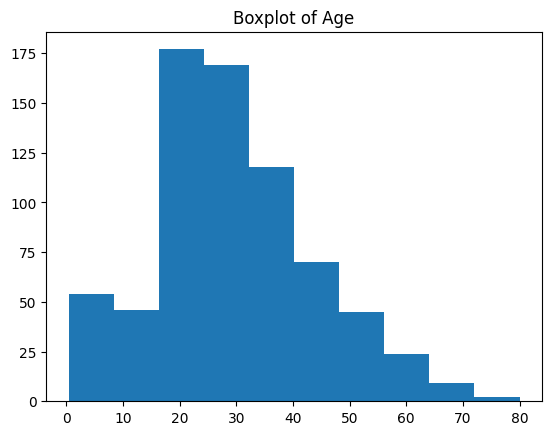

Outliers:
 33     66.0
54     65.0
96     71.0
116    70.5
280    65.0
456    65.0
493    71.0
630    80.0
672    70.0
745    70.0
851    74.0
Name: Age, dtype: float64

Catergory Frequency:
 Sex
male      577
female    314
Name: count, dtype: int64


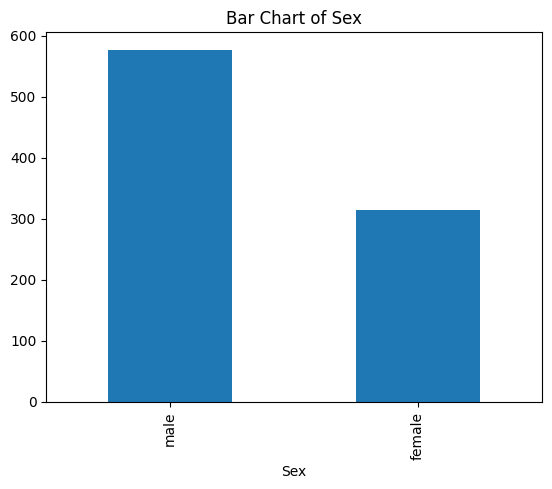

In [ ]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Titanic-Dataset.csv")

num_col = "Age"

data=df[num_col].dropna()

print("Mean: ", data.mean())
print("Median: ", data.median())
print("Mode: ", data.mode()[0])
print("Standard Deviation: ", data.std())
print("Variance: ", data.var())
print("Range: ", data.max() - data.min())

plt.hist(data, bins=10)
plt.title("Boxplot of " + num_col)
plt.show()

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data < lower) | (data > upper)]
print("Outliers:\n", outliers)

cat_col = "Sex"

freq = df[cat_col].value_counts()
print("\nCatergory Frequency:\n", freq)

freq.plot(kind='bar')
plt.title("Bar Chart of " + cat_col)
plt.show()

# Program 2

Pearson Correlation Coefficient:
               sepal_length  petal_length
sepal_length      1.000000      0.871754
petal_length      0.871754      1.000000
Covariance Matrix:
               sepal_length  petal_length
sepal_length      0.685694      1.274315
petal_length      1.274315      3.116278


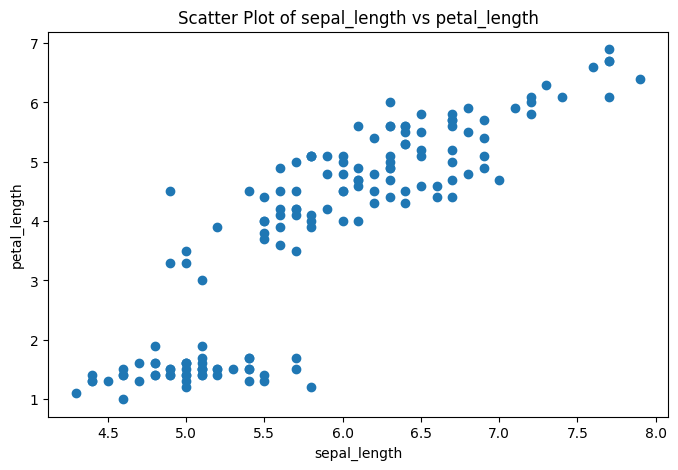

Covariance Matrix: 
               sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006

 Correlation Matrix:
               sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


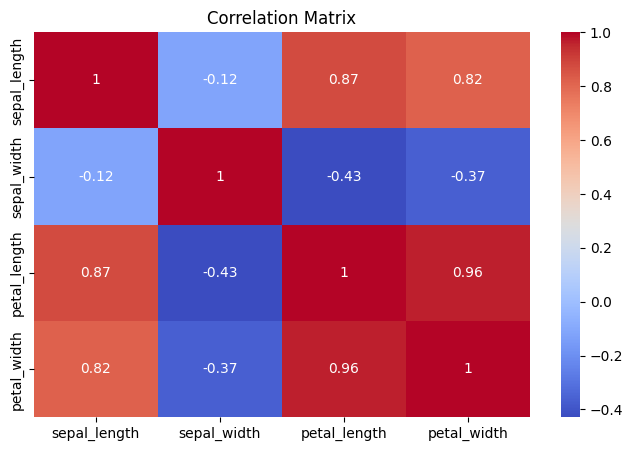

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = sns.load_dataset('iris')

x_col='sepal_length'
y_col='petal_length'

correlation = data[['sepal_length','petal_length']].corr("pearson")
print("Pearson Correlation Coefficient:\n", correlation)

#to calculate covariance matrix
covariance = data[['sepal_length','petal_length']].cov()
print("Covariance Matrix:\n", covariance)


# to get scatter plot
plt.figure(figsize=(8,5))
plt.scatter(data[x_col], data[y_col])
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f"Scatter Plot of {x_col} vs {y_col}")
plt.show()

# to calculte covariancea and correltaion from dataset
data_co =data.iloc[:,:-1]
covariance_matrix=data_co.cov()
correlation_matrix=data_co.corr()
print("Covariance Matrix: \n", covariance_matrix)
print("\n Correlation Matrix:\n", correlation_matrix)


#to get heatmap

plt.figure(figsize=(8,5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Program 3

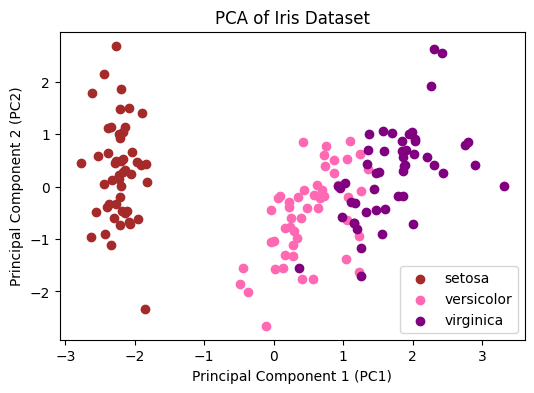

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data # Features (4 dimensions)
y = iris.target

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Species'] = y

plt.figure(figsize=(6, 4))
species = ['Setosa', 'Versicolor', 'Virginica']
colors = ['brown', 'hotpink', 'purple']

for species, color in zip(np.unique(y), colors):
    plt.scatter(df_pca.loc[df_pca['Species'] == species, 'PC1'],
                df_pca.loc[df_pca['Species'] == species, 'PC2'],
                c=color, label=iris.target_names[species])

plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('PCA of Iris Dataset')
plt.legend()
plt.show()

# Program 4

In [ ]:
# import the libraries
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target  # Labels

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Function to evaluate k-NN for different values of k
def cls_knn(X_train, X_test, y_train, y_test, k_values, weighted=False):
    results = {}
    for k in k_values:
        if weighted:
            # Weighted k-NN
            knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
        else:
            # Regular k-NN
            knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')

        # Train the model
        knn.fit(X_train, y_train)

        # Make predictions
        y_pred = knn.predict(X_test)

        # Calculate accuracy and F1-score
        accuracy = accuracy_score(y_test, y_pred)

        # Weighted F1-score for multi-class
        f1 = f1_score(y_test, y_pred, average='weighted')

        results[k] = {'accuracy': accuracy, 'f1_score': f1}

    return results


# Test for different values of k
k_values = [1, 3, 5]

# Evaluate regular k-NN
print("Regular k-NN Results:")
regular_results = cls_knn(X_train, X_test, y_train, y_test, k_values, weighted=False)

for k, metrics in regular_results.items():
    print(f"k={k}: Accuracy={metrics['accuracy']:.2f}, F1-Score={metrics['f1_score']:.2f}")


# Evaluate weighted k-NN
print("\nWeighted k-NN Results:")
weighted_results = cls_knn(X_train, X_test, y_train, y_test, k_values, weighted=True)

for k, metrics in weighted_results.items():
    print(f"k={k}: Accuracy={metrics['accuracy']:.2f}, F1-Score={metrics['f1_score']:.2f}")


# Compare performance
print("\nComparison of Regular k-NN and Weighted k-NN:")
for k in k_values:
    regular_acc = regular_results[k]['accuracy']
    weighted_acc = weighted_results[k]['accuracy']
    print(f"k={k}: Regular k-NN Accuracy={regular_acc:.2f}, Weighted k-NN Accuracy={weighted_acc:.2f}")

Regular k-NN Results:
k=1: Accuracy=1.00, F1-Score=1.00
k=3: Accuracy=1.00, F1-Score=1.00
k=5: Accuracy=1.00, F1-Score=1.00

Weighted k-NN Results:
k=1: Accuracy=1.00, F1-Score=1.00
k=3: Accuracy=1.00, F1-Score=1.00
k=5: Accuracy=1.00, F1-Score=1.00

Comparison of Regular k-NN and Weighted k-NN:
k=1: Regular k-NN Accuracy=1.00, Weighted k-NN Accuracy=1.00
k=3: Regular k-NN Accuracy=1.00, Weighted k-NN Accuracy=1.00
k=5: Regular k-NN Accuracy=1.00, Weighted k-NN Accuracy=1.00


# Program 5

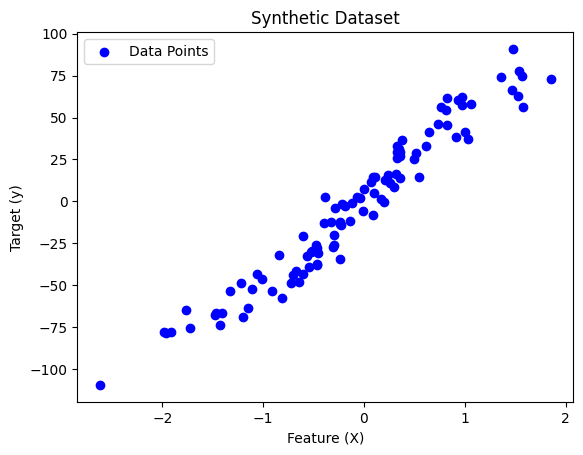

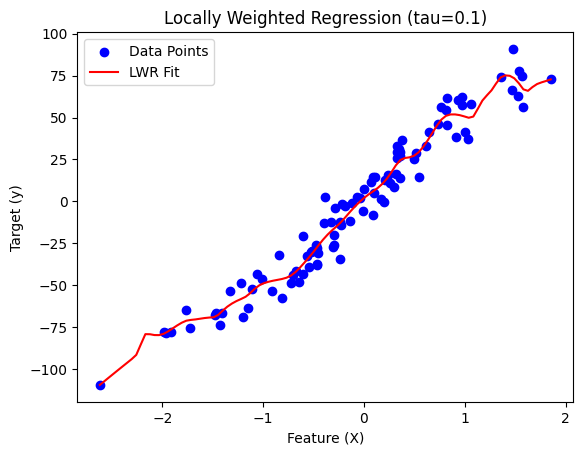

Mean Squared Error (MSE) on Training Data: 64.7316


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

# Generate a synthetic dataset
np.random.seed(42)
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

# Add some non-linearity to the dataset
y = y + 10 * np.sin(X[:, 0] * 2)

# Plot the dataset
plt.scatter(X, y, color='blue', label='Data Points')
plt.title("Synthetic Dataset")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.legend()
plt.show()


# Locally Weighted Regression function
def locally_weighted_regression(X, y, query_point, tau=0.1):
    # Compute weights using a Gaussian kernel
    weights = np.exp(-np.sum((X - query_point) ** 2, axis=1) / (2 * tau ** 2))

    # Add a bias term to X
    X_bias = np.c_[np.ones(X.shape[0]), X]

    # Compute the weighted least squares solution
    W = np.diag(weights)
    theta = np.linalg.inv(X_bias.T @ W @ X_bias) @ (X_bias.T @ W @ y)

    # Predict the target value for the query point
    query_point_bias = np.array([1, query_point[0]])
    y_pred = query_point_bias @ theta

    return y_pred


# Predict using Locally Weighted Regression
def predict_lwr(X_train, y_train, X_test, tau=0.1):
    y_pred = np.zeros(X_test.shape[0])
    for i, query_point in enumerate(X_test):
        y_pred[i] = locally_weighted_regression(X_train, y_train, query_point, tau)
    return y_pred


# Generate test points
X_test = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Predict using LWR
tau = 0.1  # Bandwidth parameter
y_pred = predict_lwr(X, y, X_test, tau)

# Plot the results
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X_test, y_pred, color='red', label='LWR Fit')
plt.title(f"Locally Weighted Regression (tau={tau})")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.legend()
plt.show()


# Evaluate the model
mse = mean_squared_error(y, predict_lwr(X, y, X, tau))
print(f"Mean Squared Error (MSE) on Training Data: {mse:.4f}")

# Program 6

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
boston_df = pd.read_csv("Boston_Housing_Data.csv")
print("Linear Regression on Boston Housing Dataset")

# Select feature and target
X = boston_df[['RM']]   # Using 'RM' (average number of rooms) as the feature
y = boston_df['MEDV']   # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train the Linear Regression model
LR_model = LinearRegression()
LR_model.fit(X_train, y_train)

# Make predictions
y_pred = LR_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

# Plot the results
plt.scatter(X_test, y_test, color='green', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Price (MEDV)")
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Boston_Housing_Data.csv'